# 커피 가격, 5거래일 뒤를 예측해 보기

2016~2025년 Parquet 12개를 묶고, **아무 변화도 없다고 보는 예측 → Ridge → CatBoost** 순서로 비교한다. 가격에서 만든 피처는 Close만 사용한다. OHLC를 억지로 보정하지 않으려는 선택이다.

예측 기준은 거래일 T의 **UTC 23:00**. 아래에서는 자료를 관측일보다 늦게 붙이고 학습 경계도 비운다. 다만 저장된 파일에는 과거 발표시각과 수정 전 값이 없다. 이번 결과는 **공개 지연을 가정한 과거 데이터 벤치마크**이며, 당시 실제로 받을 수 있었던 데이터 전체를 재현한 실험은 아니다.

In [1]:
import platform
import matplotlib.pyplot as plt

# 운영체제에 맞는 한글 폰트를 먼저 설정한다.
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":  # macOS
    plt.rc("font", family="AppleGothic")
else:  # Linux / Colab
    # 나눔고딕이 없으면 Ubuntu/Colab에서 아래 명령을 실행한 뒤 커널을 재시작한다.
    # !apt-get -qq install -y fonts-nanum
    plt.rc("font", family="NanumGothic")

plt.rc("axes", unicode_minus=False)  # 음수 축 눈금도 깨지지 않게 표시한다.


In [2]:
from pathlib import Path

import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import seaborn as sns
from catboost import CatBoostRegressor
from IPython.display import Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd() if (Path.cwd() / "configs").is_dir() else Path.cwd().parent
DATA_DIR = ROOT / "data/processed/2016-01-01_2025-12-31"
SEED = 42
TARGET = "future_log_return_5d"
# Seaborn 테마가 앞에서 고른 한글 폰트를 덮어쓰지 않게 한다.
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind", font=plt.rcParams["font.family"][0])
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False, "grid.alpha": 0.25})
pd.set_option("display.max_rows", 25)

region_labels = {
    "br_alta_mogiana": "브라질 알타 모지아나",
    "br_cerrado": "브라질 세라도",
    "br_sul_minas": "브라질 술 지 미나스",
    "co_antioquia": "콜롬비아 안티오키아",
    "co_caldas": "콜롬비아 칼다스",
    "co_huila": "콜롬비아 우일라",
}
source_labels = {
    "coffee": "아라비카 선물 (KC=F)", "brl": "브라질 환율 (BRL/USD)",
    "dff": "미국 연방기금금리", "dtwexbgs": "광의 달러지수",
    "dcoilwtico": "WTI 현물가격", "cot": "투자자 포지션 (COT)",
    **{f"weather_{region}": f"{label} 기상" for region, label in region_labels.items()},
}
feature_labels = {
    "log_return_1d": "1거래일 로그수익률", "log_return_5d": "5거래일 로그수익률",
    "log_return_20d": "20거래일 로그수익률", "volatility_20d": "20거래일 변동성",
    "brl_close": "브라질 환율 (BRL/USD)", "dff": "미국 연방기금금리",
    "dtwexbgs": "광의 달러지수", "dcoilwtico": "WTI 현물가격",
    "cot_net_ratio": "매니지드 머니 순매수 비율", TARGET: "5거래일 뒤 로그수익률",
}
for region, label in region_labels.items():
    feature_labels[f"{region}_rain_30d"] = f"{label} · 30일 누적 강수량"
    feature_labels[f"{region}_temp_30d"] = f"{label} · 30일 평균 기온"
model_labels = {"Naive Persistence": "가격 유지 (Naive)", "Ridge Regression": "Ridge 회귀", "CatBoost": "CatBoost"}
metric_labels = {"MAE": "평균절대오차 (MAE)", "RMSE": "제곱평균제곱근오차 (RMSE)",
                 "Directional Accuracy (%)": "방향성 정확도 (%)"}

sources = {}
for path in sorted(DATA_DIR.glob("*.parquet")):
    frame = pd.read_parquet(path).sort_values("date").reset_index(drop=True)
    frame["date"] = pd.to_datetime(frame["date"]).astype("datetime64[ns]")
    assert frame["date"].notna().all() and frame["date"].is_unique, path.name
    sources[path.stem] = frame
assert len(sources) == 12

display(
    pd.DataFrame(
        [
            {
                "source": source_labels[name],
                "rows": len(frame),
                "start": frame.date.min().date(),
                "end": frame.date.max().date(),
                "missing_cells": int(frame.isna().sum().sum()),
            }
            for name, frame in sources.items()
        ]
    ).set_index("source").rename_axis("데이터").rename(columns={
        "rows": "행 수", "start": "시작일", "end": "종료일", "missing_cells": "결측 셀 수",
    })
)

,행 수,시작일,종료일,결측 셀 수
데이터,,,,
브라질 환율 (BRL/USD),2609,2016-01-01,2025-12-31,28
아라비카 선물 (KC=F),2519,2016-01-04,2025-12-31,16
투자자 포지션 (COT),522,2016-01-05,2025-12-30,0
WTI 현물가격,2609,2016-01-01,2025-12-31,108
미국 연방기금금리,3653,2016-01-01,2025-12-31,0
광의 달러지수,2609,2016-01-01,2025-12-31,117
브라질 알타 모지아나 기상,3653,2016-01-01,2025-12-31,0
브라질 세라도 기상,3653,2016-01-01,2025-12-31,0
브라질 술 지 미나스 기상,3653,2016-01-01,2025-12-31,0


## 1. 날짜부터 맞추기

결측 행을 먼저 지우면 `shift(-5)`가 원래보다 먼 날짜를 가리킬 수 있다. 그래서 거래일 칸부터 만들고, 빠진 가격은 NaN으로 남긴다. 가격을 앞으로 채워 가짜 수익률을 만들지는 않는다.

미국 공통 휴장일은 NYSE 달력을 바탕으로 잡고, ICE가 개장한 [2018-12-05](https://www.ice.com/publicdocs/clear_us/notices/18-054_IFUS_ICUS_President_HW_Bush.pdf)와 [2025-01-09](https://www.ice.com/publicdocs/clear_us/notices/25-002_ICUS_President_Jimmy_Carter.pdf)는 따로 더했다. Yahoo에 값이 있는 [2023년 추수감사절](https://www.ice.com/publicdocs/futures_us/exchange_notices/ICE_Futures_US_2023Thanksgiving_Holiday_20230921.pdf)과 [2025년 독립기념일](https://www.ice.com/publicdocs/futures_us/exchange_notices/ICE_Futures_US_2025_IndDayHoliday_20250508.pdf)은 Coffee 휴장일이라 제외한다. 아래 표는 이 달력과 원본의 차이다. 원본 Parquet는 바꾸지 않는다.

In [3]:
coffee = sources["coffee"].set_index("date")
sessions = mcal.get_calendar("NYSE").valid_days("2016-01-01", "2025-12-31").tz_localize(None)
sessions = sessions.union(pd.to_datetime(["2018-12-05", "2025-01-09"])).sort_values()
sessions = sessions.as_unit("ns")
excluded = coffee.index.difference(sessions)
missing = sessions.difference(coffee.index)
display(
    pd.concat(
        [
            pd.DataFrame({"date": excluded, "status": "휴장일 행 제외"}),
            pd.DataFrame({"date": missing, "status": "누락 거래일은 결측으로 유지"}),
        ]
    )
    .sort_values("date")
    .reset_index(drop=True).rename(columns={"date": "날짜", "status": "처리 내용"})
)

prices = coffee[["close"]].reindex(sessions).rename_axis("date").reset_index()
log_close = np.log(prices["close"].where(prices["close"] > 0))
PRICE_FEATURES = ["log_return_1d", "log_return_5d", "log_return_20d", "volatility_20d"]
for lag in (1, 5, 20):
    prices[f"log_return_{lag}d"] = log_close.diff(lag)
prices["volatility_20d"] = prices["log_return_1d"].rolling(20, min_periods=20).std()
prices[TARGET] = log_close.shift(-5) - log_close
prices["target_date"] = prices["date"].shift(-5)
prices["future_close"] = prices["close"].shift(-5)
prices["prediction_at"] = prices["date"] + pd.Timedelta(hours=23)  # 시각은 모두 UTC
assert prices["target_date"].iloc[:-5].reset_index(drop=True).equals(prices["date"].iloc[5:].reset_index(drop=True))

,날짜,처리 내용
0,2016-01-18,휴장일 행 제외
1,2016-02-15,휴장일 행 제외
2,2016-10-10,누락 거래일은 결측으로 유지
3,2016-11-11,누락 거래일은 결측으로 유지
4,2018-12-05,누락 거래일은 결측으로 유지
5,2023-11-23,휴장일 행 제외
6,2025-05-26,휴장일 행 제외
7,2025-06-19,휴장일 행 제외
8,2025-07-04,휴장일 행 제외


## 2. 관측일과 쓸 수 있는 날짜 구분하기

날짜가 같다고 바로 붙이기에는 공개 주기가 다르다. [광의 달러지수는 전주 자료를 주 단위로 공개](https://www.federalreserve.gov/releases/h10/about.htm)하고, [COT는 보통 화요일 포지션을 금요일에 공개](https://www.cftc.gov/MarketReports/CommitmentsofTraders/ReleaseSchedule/index.htm)한다. [NASA 기상 자료도 며칠 늦게 들어오며](https://power.larc.nasa.gov/docs/faqs/data/), [나중에 자료가 교체될 수 있다](https://power.larc.nasa.gov/docs/methodology/data/sources/).

아래 일수는 정확한 발표시각 대신 여유를 둔 **달력일 기준 가정**이다. BRL 1일, DFF 4일, 달러지수 14일, WTI 7일, 기상 4일, COT 7일. FRED는 과거 방향으로만 채우고, `merge_asof(direction="backward")`로 T 이전에 사용 가능한 마지막 값을 가져온다.

COT의 큰 발표 지연은 [2019년 재개 일정](https://www.cftc.gov/PressRoom/PressReleases/7864-19)과 [2023·2025년 특별 공지](https://www.cftc.gov/MarketReports/CommitmentsofTraders/HistoricalSpecialAnnouncements/index.htm)를 반영했다. 해당 보고서는 기본 지연일과 공지된 발표일 다음 날 중 더 늦은 날부터 사용한다.

In [4]:
LAG_DAYS = {"brl": 1, "dff": 4, "dtwexbgs": 14, "dcoilwtico": 7, "weather": 4, "cot": 7}
joined = prices.copy()
FEATURES = PRICE_FEATURES.copy()
join_checks = []


def join_source(left, right, name, columns, lag_days):
    right = right.copy()
    if "available_at" not in right:
        right["available_at"] = right["date"] + pd.Timedelta(days=lag_days)
    observed, available = f"{name}_observed_at", f"{name}_available_at"
    right = right.rename(columns={"date": observed, "available_at": available})
    result = pd.merge_asof(
        left.sort_values("prediction_at"),
        right[[observed, available, *columns]].sort_values(available),
        left_on="prediction_at",
        right_on=available,
        direction="backward",
    )
    matched = result[available].notna()
    assert len(result) == len(left)
    assert (result.loc[matched, available] <= result.loc[matched, "prediction_at"]).all()
    assert (result.loc[matched, observed] <= result.loc[matched, available]).all()
    join_checks.append({"source": name, "matched_rows": int(matched.sum()), "total_rows": len(result)})
    return result


brl = sources["brl"][["date", "close"]].rename(columns={"close": "brl_close"}).dropna()
joined = join_source(joined, brl, "brl", ["brl_close"], LAG_DAYS["brl"])
FEATURES.append("brl_close")
for name in ("dff", "dtwexbgs", "dcoilwtico"):
    fred = sources[name][["date", "value"]].copy()
    fred[name] = fred.pop("value").ffill()  # 휴일의 빈칸도 이전 값만 사용한다
    joined = join_source(joined, fred, name, [name], LAG_DAYS[name])
    FEATURES.append(name)

for name, frame in sources.items():
    if not name.startswith("weather_"):
        continue
    region = name.removeprefix("weather_")
    daily = frame.set_index("date").asfreq("D")
    rain, temp = f"{region}_rain_30d", f"{region}_temp_30d"
    # 기상 30일은 달력일이다. 거래일에 붙이기 전에 산지별로 집계한다.
    weather = pd.DataFrame(
        {
            rain: daily["PRECTOTCORR"].rolling("30D", min_periods=30).sum(),
            temp: daily["T2M"].rolling("30D", min_periods=30).mean(),
        }
    ).reset_index()
    joined = join_source(joined, weather, name, [rain, temp], LAG_DAYS["weather"])
    FEATURES.extend([rain, temp])

In [5]:
cot = sources["cot"].copy()
cot["cot_net_ratio"] = (cot["managed_money_long"] - cot["managed_money_short"]) / cot["open_interest"].replace(
    0, np.nan
)
cot["available_at"] = cot["date"] + pd.Timedelta(days=LAG_DAYS["cot"])

# 보고 기준일 순서의 발표 일정. 발표가 멈춘 동안 새 포지션을 미리 쓰지 않는다.
cot_release_delays = [
    (
        "2018-12-24",
        "2019-03-05",
        "2019-02-01 2019-02-05 2019-02-08 2019-02-12 2019-02-15 2019-02-19 "
        "2019-02-22 2019-02-26 2019-03-01 2019-03-05 2019-03-08",
    ),
    ("2023-01-31", "2023-03-14", "2023-02-24 2023-03-03 2023-03-08 2023-03-10 2023-03-14 2023-03-16 2023-03-21"),
    (
        "2025-09-30",
        "2025-12-23",
        "2025-11-19 2025-11-21 2025-11-25 2025-12-02 2025-12-05 2025-12-09 "
        "2025-12-10 2025-12-12 2025-12-15 2025-12-17 2025-12-19 2025-12-23 2025-12-29",
    ),
]
for start, end, release_days in cot_release_delays:
    mask = cot["date"].between(start, end)
    release_after = pd.to_datetime(release_days.split()) + pd.Timedelta(days=1)
    assert mask.sum() == len(release_after)
    cot.loc[mask, "available_at"] = np.maximum(cot.loc[mask, "available_at"].to_numpy(), release_after.to_numpy())

joined = join_source(joined, cot, "cot", ["cot_net_ratio"], LAG_DAYS["cot"])
FEATURES.append("cot_net_ratio")
assert len(FEATURES) == len(set(FEATURES)) == 21
assert TARGET not in FEATURES and "future_close" not in FEATURES
# 가격과 정답은 보간하지 않는다. 외부 피처 결측은 학습 구간 중앙값으로 채운다.
data = joined.dropna(subset=["close", "target_date", TARGET, *PRICE_FEATURES]).copy()
assert np.isfinite(data[FEATURES].dropna().to_numpy()).all()
display(pd.DataFrame(join_checks).set_index("source").rename(index=source_labels).rename_axis("데이터").rename(
    columns={"matched_rows": "연결된 행 수", "total_rows": "전체 행 수"}
))

,연결된 행 수,전체 행 수
데이터,,
브라질 환율 (BRL/USD),2516,2516
미국 연방기금금리,2515,2516
광의 달러지수,2507,2516
WTI 현물가격,2512,2516
브라질 알타 모지아나 기상,2515,2516
브라질 세라도 기상,2515,2516
브라질 술 지 미나스 기상,2515,2516
콜롬비아 안티오키아 기상,2515,2516
콜롬비아 칼다스 기상,2515,2516


## 3. EDA와 시간 순서 분할

2016~2021년으로 학습하고 2022~2023년으로 설정을 고른다. 그다음 2016~2023년으로 다시 학습해 2024~2025년을 한 번 평가한다. 타깃 날짜가 다음 구간으로 넘어가는 마지막 5거래일은 학습·검증에서 뺀다.

EDA도 개발 구간에서만 본다. 30일 기상 피처의 초반 결측, 수익률 분포, COT 비율 정도부터 확인한다. 외부 피처의 결측을 채울 중앙값과 Ridge의 스케일은 각 학습 구간 안에서만 구한다.

In [6]:
VAL_START = pd.Timestamp("2022-01-01")
TEST_START = pd.Timestamp("2024-01-01")
TEST_END = pd.Timestamp("2025-12-31")
train = data.loc[(data["date"] < VAL_START) & (data["target_date"] < VAL_START)]
val = data.loc[data["date"].between(VAL_START, TEST_START, inclusive="left") & (data["target_date"] < TEST_START)]
dev = data.loc[(data["date"] < TEST_START) & (data["target_date"] < TEST_START)]
test = data.loc[data["date"].between(TEST_START, TEST_END) & (data["target_date"] <= TEST_END)]
assert train["target_date"].max() < val["date"].min()
assert dev["target_date"].max() < test["date"].min()
assert set(dev.index).isdisjoint(test.index)

display(
    pd.DataFrame(
        [
            {
                "split": name,
                "rows": len(frame),
                "first_origin": frame.date.min().date(),
                "last_origin": frame.date.max().date(),
                "last_target": frame.target_date.max().date(),
            }
            for name, frame in [("학습", train), ("검증", val), ("재학습 (2016~2023)", dev), ("테스트", test)]
        ]
    ).set_index("split").rename_axis("구간").rename(columns={
        "rows": "행 수", "first_origin": "첫 예측 기준일", "last_origin": "마지막 예측 기준일", "last_target": "마지막 정답 날짜",
    })
)
eda_columns = [*PRICE_FEATURES, "cot_net_ratio", TARGET]
display(dev[eda_columns].describe(percentiles=[0.05, 0.5, 0.95]).T.round(4).rename(
    index=feature_labels, columns={"count": "관측 수", "mean": "평균", "std": "표준편차", "min": "최솟값",
                                 "5%": "5% 분위", "50%": "중앙값", "95%": "95% 분위", "max": "최댓값"},
).rename_axis("피처"))
missing_pct = dev[FEATURES].isna().mean().mul(100)
display(missing_pct[missing_pct > 0].rename(index=feature_labels).rename("개발 구간 결측률 (%)").round(2).to_frame().rename_axis("피처"))

,행 수,첫 예측 기준일,마지막 예측 기준일,마지막 정답 날짜
구간,,,,
학습,1422,2016-02-02,2021-12-23,2021-12-31
검증,496,2022-01-03,2023-12-21,2023-12-29
재학습 (2016~2023),1923,2016-02-02,2023-12-21,2023-12-29
테스트,498,2024-01-02,2025-12-23,2025-12-31


,관측 수,평균,표준편차,최솟값,5% 분위,중앙값,95% 분위,최댓값
피처,,,,,,,,
1거래일 로그수익률,1923.0,0.0003,0.0205,-0.0902,-0.0327,-0.0004,0.0352,0.0956
5거래일 로그수익률,1923.0,0.0017,0.0453,-0.1844,-0.0661,-0.0007,0.0782,0.2915
20거래일 로그수익률,1923.0,0.0064,0.0852,-0.2691,-0.1284,0.0000,0.1514,0.2787
20거래일 변동성,1923.0,0.0197,0.0057,0.0078,0.0122,0.0186,0.0293,0.0467
매니지드 머니 순매수 비율,1923.0,-0.0115,0.1558,-0.3471,-0.2543,0.0184,0.1941,0.2653
5거래일 뒤 로그수익률,1923.0,0.0013,0.0454,-0.1844,-0.0663,-0.0014,0.0782,0.2915


,개발 구간 결측률 (%)
피처,
브라질 알타 모지아나 · 30일 누적 강수량,0.05
브라질 알타 모지아나 · 30일 평균 기온,0.05
브라질 세라도 · 30일 누적 강수량,0.05
브라질 세라도 · 30일 평균 기온,0.05
브라질 술 지 미나스 · 30일 누적 강수량,0.05
브라질 술 지 미나스 · 30일 평균 기온,0.05
콜롬비아 안티오키아 · 30일 누적 강수량,0.05
콜롬비아 안티오키아 · 30일 평균 기온,0.05
콜롬비아 칼다스 · 30일 누적 강수량,0.05


## 4. 기준 모델 세 개

Ridge는 alpha 네 개만 비교한다. CatBoost는 깊이 4로 작게 시작하고, 검증 RMSE가 더 좋아지지 않으면 멈춘다. 테스트 결과를 보고 설정을 다시 고르지는 않는다.

방향성 정확도는 `sign(실제 수익률) == sign(예측 수익률)`의 비율이다. **0은 보합**으로 센다. 그래서 항상 0을 내는 Naive는 실제 수익률도 0일 때만 방향을 맞힌다. 이 모델의 주 비교 기준은 MAE·RMSE다.

In [7]:
ridge_trials = []
for alpha in (0.1, 1.0, 10.0, 100.0):
    candidate = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=alpha))
    candidate.fit(train[FEATURES], train[TARGET])
    ridge_trials.append(
        {"alpha": alpha, "val_rmse": root_mean_squared_error(val[TARGET], candidate.predict(val[FEATURES]))}
    )
ridge_trials = pd.DataFrame(ridge_trials).sort_values("val_rmse")
best_alpha = float(ridge_trials.iloc[0]["alpha"])

cat_params = dict(
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=4,
    allow_writing_files=False,
    verbose=False,
)
cat_imputer = SimpleImputer(strategy="median").fit(train[FEATURES])
cat_search = CatBoostRegressor(iterations=1000, **cat_params)
cat_search.fit(
    cat_imputer.transform(train[FEATURES]),
    train[TARGET],
    eval_set=(cat_imputer.transform(val[FEATURES]), val[TARGET]),
    early_stopping_rounds=100,
    use_best_model=True,
)
best_iterations = int(cat_search.best_iteration_) + 1
val_scores = pd.DataFrame(
    [
        {"model": "가격 유지 (수익률 0)", "val_rmse": root_mean_squared_error(val[TARGET], np.zeros(len(val)))},
        {"model": f"Ridge 회귀 (규제 강도={best_alpha:g})", "val_rmse": ridge_trials.iloc[0]["val_rmse"]},
        {
            "model": f"CatBoost (트리 {best_iterations}개)",
            "val_rmse": root_mean_squared_error(val[TARGET], cat_search.predict(cat_imputer.transform(val[FEATURES]))),
        },
    ]
).set_index("model")
display(val_scores.round(6).rename_axis("모델").rename(columns={"val_rmse": "검증 오차 (RMSE)"}))

,검증 오차 (RMSE)
모델,
가격 유지 (수익률 0),0.047069
Ridge 회귀 (규제 강도=100),0.050048
CatBoost (트리 31개),0.047150


In [8]:
ridge = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=best_alpha))
ridge.fit(dev[FEATURES], dev[TARGET])
final_imputer = SimpleImputer(strategy="median").fit(dev[FEATURES])
catboost = CatBoostRegressor(iterations=best_iterations, **cat_params)
catboost.fit(final_imputer.transform(dev[FEATURES]), dev[TARGET])

predictions = pd.DataFrame(
    {
        "Naive Persistence": np.zeros(len(test)),
        "Ridge Regression": ridge.predict(test[FEATURES]),
        "CatBoost": catboost.predict(final_imputer.transform(test[FEATURES])),
    },
    index=test.index,
)
assert np.isfinite(predictions.to_numpy()).all()
metrics = pd.DataFrame(
    [
        {
            "model": name,
            "MAE": mean_absolute_error(test[TARGET], pred),
            "RMSE": root_mean_squared_error(test[TARGET], pred),
            "Directional Accuracy (%)": np.mean(np.sign(test[TARGET]) == np.sign(pred)) * 100,
        }
        for name, pred in predictions.items()
    ]
).set_index("model")
display(metrics.rename(index=model_labels, columns=metric_labels).rename_axis("모델").style.format({
    metric_labels["MAE"]: "{:.6f}", metric_labels["RMSE"]: "{:.6f}", metric_labels["Directional Accuracy (%)"]: "{:.2f}",
}))
print(f"테스트 예측 {len(test):,}건 | Ridge 규제 강도={best_alpha:g} | CatBoost 트리 {best_iterations}개")

,평균절대오차 (MAE),제곱평균제곱근오차 (RMSE),방향성 정확도 (%)
모델,,,
가격 유지 (Naive),0.042810,0.054442,0.40
Ridge 회귀,0.044319,0.057085,46.79
CatBoost,0.042976,0.054631,48.19


테스트 예측 498건 | Ridge 규제 강도=100 | CatBoost 트리 31개


## 5. 모델이 주로 본 피처

CatBoost의 내장 중요도(PredictionValuesChange)를 본다. 전체 피처의 합이 100이 되며, 이 중 상위 10개만 그린다. 학습한 모델이 많이 사용한 피처라는 뜻이지, 그 변수가 가격을 움직였다는 뜻은 아니다.

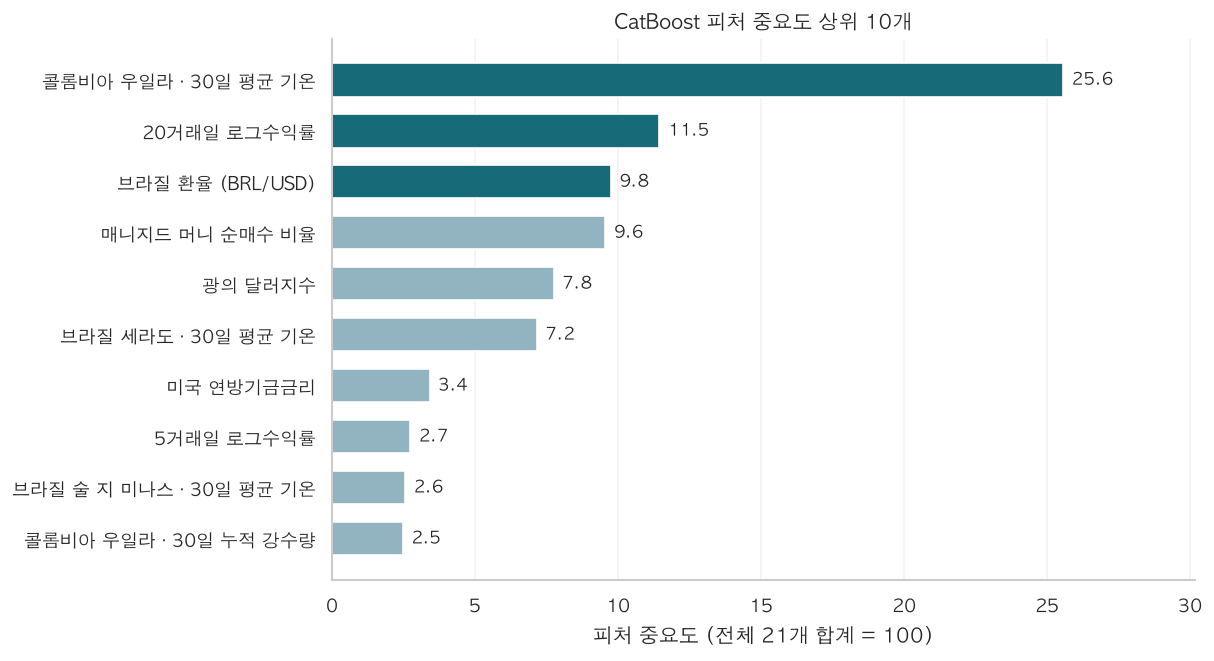

In [9]:
importance = pd.Series(catboost.feature_importances_, index=FEATURES, name="importance").sort_values(ascending=False)
top10 = importance.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5.4), layout="constrained")
bars = ax.barh(top10.index.map(feature_labels), top10.values, color=["#91B4C0"] * 7 + ["#176B78"] * 3, height=0.65)
ax.bar_label(bars, fmt="%.1f", padding=5, fontsize=10)
ax.set(title="CatBoost 피처 중요도 상위 10개", xlabel="피처 중요도 (전체 21개 합계 = 100)", ylabel="")
ax.set_xlim(0, top10.max() * 1.18)
ax.grid(axis="y", visible=False)
plt.show()

## 6. 예측 수익률을 가격으로 돌려 보기

예측 가격은 `Close[T] × exp(예측 수익률)`이고, **T가 아니라 T+5 거래일 날짜**에 그린다. 매일 새로 계산한 5일 앞 예측을 이어 그린 것이므로 2년치를 한 번에 예측한 곡선은 아니다. 현재 가격을 출발점으로 쓰기 때문에 선이 비슷하게 보여도, 성능은 위의 수익률 오차와 Naive 비교로 판단한다.

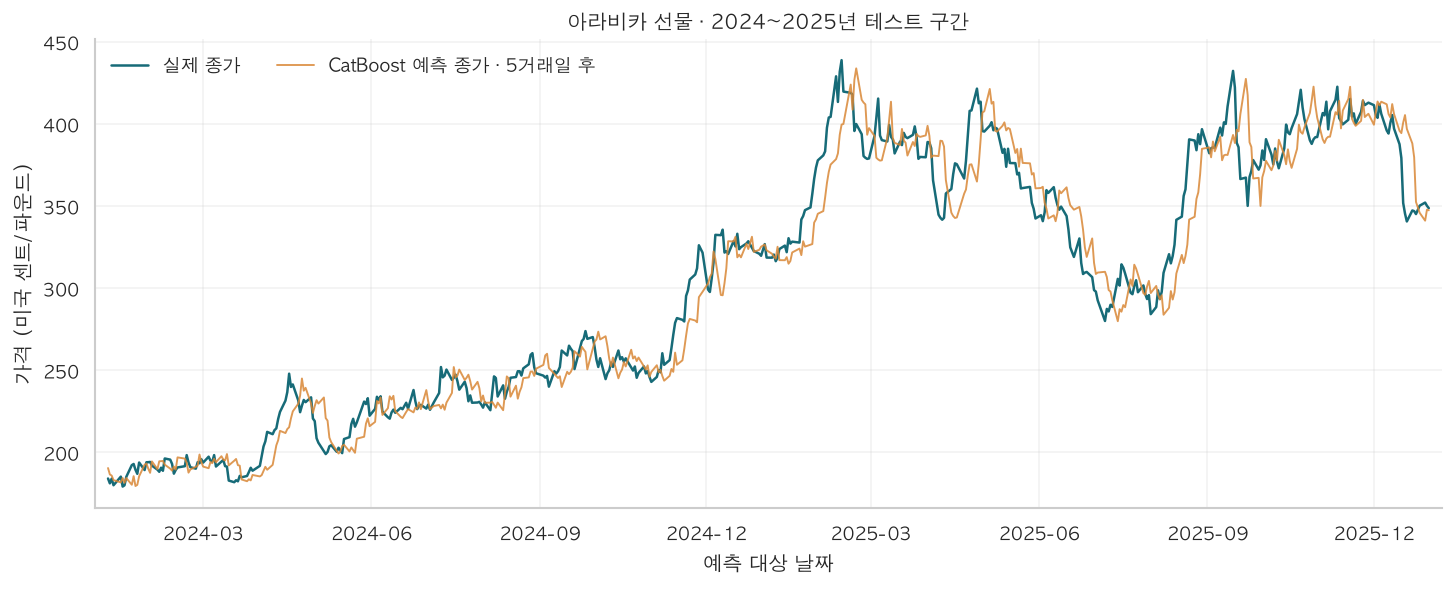

In [10]:
price_comparison = pd.DataFrame(
    {
        "target_date": test["target_date"],
        "Actual close": test["future_close"],
        "CatBoost forecast": test["close"] * np.exp(predictions["CatBoost"]),
    }
).set_index("target_date")
fig, ax = plt.subplots(figsize=(12, 4.8), layout="constrained")
ax.plot(price_comparison.index, price_comparison["Actual close"], label="실제 종가", color="#176B78", linewidth=1.5)
ax.plot(
    price_comparison.index,
    price_comparison["CatBoost forecast"],
    label="CatBoost 예측 종가 · 5거래일 후",
    color="#D98736",
    linewidth=1.15,
    alpha=0.85,
)
ax.set(title="아라비카 선물 · 2024~2025년 테스트 구간", xlabel="예측 대상 날짜", ylabel="가격 (미국 센트/파운드)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(frameon=False, loc="upper left", ncols=2)
ax.margins(x=0.01)
plt.show()

In [11]:
best_model = metrics["RMSE"].idxmin()
top_features = ", ".join(f"{feature_labels[name]} ({value:.1f})" for name, value in importance.head(3).items())
rmse_change = (metrics.loc["CatBoost", "RMSE"] / metrics.loc["Naive Persistence", "RMSE"] - 1) * 100
print(f"최저 RMSE 모델: {model_labels[best_model]} | CatBoost의 Naive 대비 RMSE 변화: {rmse_change:+.1f}%\n중요도 상위 피처: {top_features}")

최저 RMSE 모델: 가격 유지 (Naive) | CatBoost의 Naive 대비 RMSE 변화: +0.3%
중요도 상위 피처: 콜롬비아 우일라 · 30일 평균 기온 (25.6), 20거래일 로그수익률 (11.5), 브라질 환율 (BRL/USD) (9.8)


테스트 RMSE가 가장 낮은 모델은 가격 유지 모델(Naive). CatBoost RMSE는 Naive 대비 **+0.3%**다.

중요도 상위 3개는 콜롬비아 우일라 30일 평균 기온(25.6), 20거래일 로그수익률(11.5), 브라질 환율(9.8). 이 결과만으로 모델이 좋아졌다고 단정하기보다, 다음 실험에서는 가격 피처만 쓴 경우와 외부 피처를 더한 경우를 같은 구간에서 비교해보고 싶다.